## Läs in dataset
Laddar in datasetet och tittar på dess struktur:

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/gym_dataset.csv")

df = df.rename(columns={
    "weight (kg)": "weight",
    "height (m)": "height",
    "calories burned": "calories_burned"
})

print("Shape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

display(df.head())

Shape of dataset:
(973, 15)

Columns:
Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='str')


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Översikt av datan
Undersöker vilka variabler som finns och om det finns saknade värden:

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

## Val av variabler
Väljer ut de variabler som är relevanta för analysen:

In [37]:
df_reduced = df[[
    "Age",
    "Weight (kg)",
    "Height (m)",
    "Calories_Burned"
]].dropna()


## Skapa BMI
Skapar en ny variabel (BMI) för att förenkla analysen:

In [38]:
df_reduced["BMI"] = df_reduced["Weight (kg)"] / (df_reduced["Height (m)"] ** 2)

## Statistik
Sammanfattar datan med hjälp av statistik:

In [39]:
df_reduced.describe()

,Age,Weight (kg),Height (m),Calories_Burned,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,905.422405,24.912239
std,12.180928,21.207500,0.12772,272.641516,6.660920
min,18.000000,40.000000,1.50000,303.000000,12.322478
25%,28.000000,58.100000,1.62000,720.000000,20.114286
50%,40.000000,70.000000,1.71000,893.000000,24.163623
75%,49.000000,86.000000,1.80000,1076.000000,28.561128
max,59.000000,129.900000,2.00000,1783.000000,49.843756


## Samband mellan BMI och kaloriförbränning:

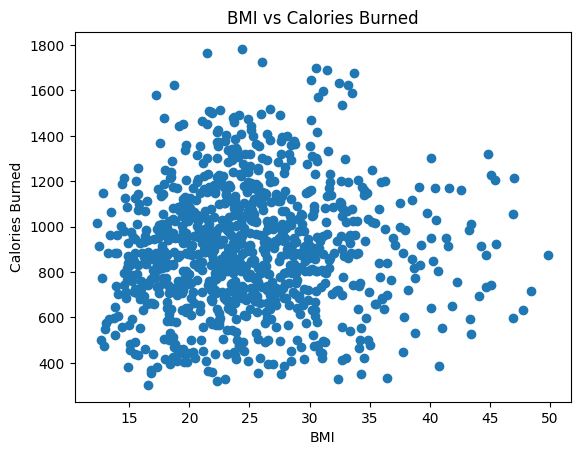

In [42]:
plt.scatter(df_reduced["BMI"], df_reduced["Calories_Burned"])
plt.xlabel("BMI")
plt.ylabel("Calories Burned")
plt.title("BMI vs Calories Burned")
plt.show()

## Fördelning av BMI
Visar hur BMI är fördelat i datasetet (histogram):

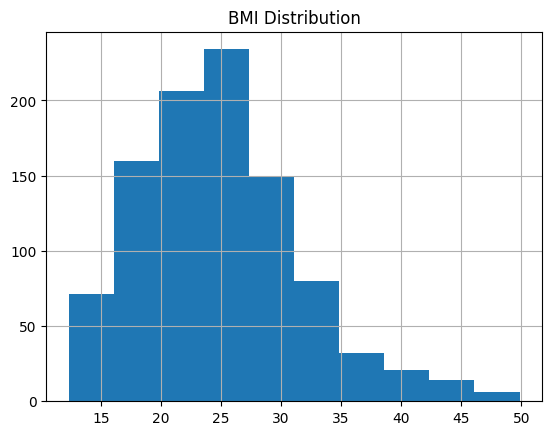

In [43]:
df_reduced["BMI"].hist()
plt.title("BMI Distribution")
plt.show()

## Identifiera avvikande värden
Använder boxplot för att se om det finns extrema värden (outliers):

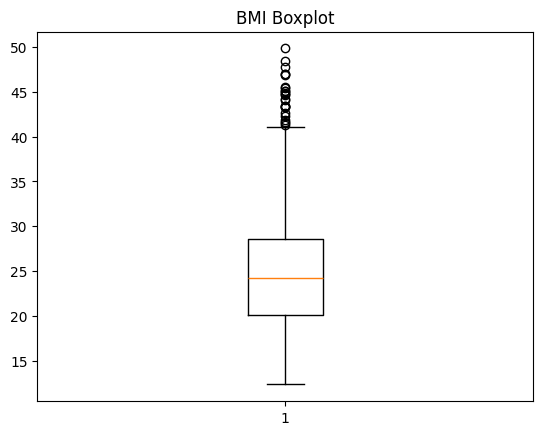

In [44]:
plt.boxplot(df_reduced["BMI"])
plt.title("BMI Boxplot")
plt.show()

## Samband mellan variabler
Undersöker om det finns samband mellan variablerna (korrelation):

In [45]:
df_reduced.corr()

,Age,Weight (kg),Height (m),Calories_Burned,BMI
Age,1.000000,-0.036340,-0.027837,-0.154679,-0.013687
Weight (kg),-0.036340,1.000000,0.365321,0.095443,0.853147
Height (m),-0.027837,0.365321,1.000000,0.086348,-0.159485
Calories_Burned,-0.154679,0.095443,0.086348,1.000000,0.059764
BMI,-0.013687,0.853147,-0.159485,0.059764,1.000000


## Filtrering av data (datareduktion)
Fokuserar på en specifik grupp (t.ex. BMI över 25):

In [46]:
df_filtered = df_reduced[df_reduced["BMI"] > 25]

## Kategorisering
Gör datan mer "förklarbar":

In [47]:
df_reduced["BMI_Category"] = df_reduced["BMI"].apply(
    lambda x: "Overweight" if x > 25 else "Normal"
)

## Tolkning
- BMI verkar vara relativt jämnt fördelat
- Det finns ett samband mellan BMI och kaloriförbränning
- Inga tydliga extrema värden identifierades

## Export av reducerad data
Sparar den bearbetade datan för vidare analys (PCA, UMAP, CA):

In [53]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_reduced.to_csv("../data/processed/emmy_dataset2_clean.csv", index=False)